# 04 — Additive models of fibrotic intensity and ring distance

This notebook asks whether gene expression and pathway activity are associated independently with continuous fibrotic NMF intensity and distance from the nearest Fibrotic niche.

For each outcome, the spot-level model is:

`standardized outcome ~ standardized fibrotic score + standardized ring distance + sample`

Only main effects are included. Interactions between fibrotic score or cell composition and ring distance are intentionally reserved for Notebook 05.

In [13]:
from collections import deque
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import sparse
from statsmodels.stats.multitest import multipletests

sc.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor="white")
sns.set_theme(style="whitegrid")

## Load the processed dataset

The analysis reuses the processed AnnData object and the same feature sets used in Notebook 03.

In [14]:
adata = sc.read_h5ad("../data/adata_vis_human_spatial_paper.h5ad")
adata

AnnData object with n_obs × n_vars = 57787 × 12486
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden_25', 'sampleID', 'treatment', 'VisiumSlides', 'technology', 'patient', 'AT0', 'AT1', 'AT2', 'Aberrant basaloid', 'Adventitial fibroblast', 'Alveolar fibroblast', 'Artery', 'B/Plasma', 'Basal', 'Basophil/Mast', 'Bronchial Vessel', 'Capillary', 'Capillary Aerocyte', 'Ciliated', 'Ciliated SFTPB+/SCGB1A1+', 'Dendritic', 'Ionocyte', 'Lymphatic', 'Macrophage C1Q hi', 'Macrophage CHI3L1+/CD9 hi/', 'Macrophage FABP4+', 'Macrophage IL1B+', 'Macrophage LYVE1+', 'Macrophage RETN+/VCAN+', 'Mesothelial', 'Monocyte', 'Mucous', 'Myofibroblast', 'NK', 'Peribronchial fibroblast', 'Pericyte', 'Smooth Muscle', 'T cell', 'TB-SC', 'Vein', 'pDC', 'preTB-SC/RAS', 'Androgen', 'EGFRsignaling', 'Estrogen', 'Hypoxia', 'JAK-STAT', 'MAPK', 'NFkB', 'p53', 'PI3K', 'TGFb', 'TNFa', 'Trail', 'VEGF', 'WNT', 'mean_nUMI_fa

In [15]:
genes = [
    "COL1A1", "COL3A1", "CTHRC1", "POSTN", "KRT7",
    "SPP1", "SFTPC", "AGER", "MUC5B", "SCGB1A1",
]

pathways = [
    "Androgen", "EGFR", "Estrogen", "Hypoxia", "JAK-STAT", "MAPK", "NFkB",
    "PI3K", "TGFb", "TNFa", "Trail", "VEGF", "WNT", "p53",
]

missing_genes = [gene for gene in genes if gene not in adata.var_names]
missing_pathways = [pathway for pathway in pathways if pathway not in adata.obsm["mlm_estimate"].columns]
assert not missing_genes, f"Missing genes: {missing_genes}"
assert not missing_pathways, f"Missing pathways: {missing_pathways}"
print(f"Genes: {len(genes)}; pathways: {len(pathways)}")

pathway_display_names = {
    "Androgen": "Androgen signaling pathway", "EGFR": "EGFR signaling pathway",
    "Estrogen": "Estrogen signaling pathway", "Hypoxia": "Hypoxia signaling pathway",
    "JAK-STAT": "JAK-STAT signaling pathway", "MAPK": "MAPK signaling pathway",
    "NFkB": "NF-κB signaling pathway", "PI3K": "PI3K signaling pathway",
    "TGFb": "TGF-β signaling pathway", "TNFa": "TNF-α signaling pathway",
    "Trail": "TRAIL signaling pathway", "VEGF": "VEGF signaling pathway",
    "WNT": "WNT signaling pathway", "p53": "p53 signaling pathway",
}
pathway_labels = [pathway_display_names[pathway] for pathway in pathways]

Genes: 10; pathways: 14


## Reconstruct fibrotic intensity and lattice distance

The processed object stores ten spot-level NMF factors. As established in Notebook 02, factor 6 is the factor most strongly associated with the Fibrotic niche. Its value is divided by the sum of all stored factor values in that spot, giving a relative fibrotic score.

Ring distance is the shortest path on the native six-neighbor Visium lattice to any spot labeled `Fibrotic`, calculated separately within each IPF section. Distances of five or more steps are capped at 5 for the regression so sparse distant spots do not dominate a linear slope.

In [16]:
factor_columns = sorted(
    [column for column in adata.obs.columns if column.startswith("mean_nUMI_factorsfact_")],
    key=lambda column: int(column.rsplit("_", 1)[-1]),
)
factor_total = adata.obs[factor_columns].sum(axis=1).replace(0, np.nan)
adata.obs["fibrotic_score"] = (
    adata.obs["mean_nUMI_factorsfact_6"] / factor_total
).fillna(0.0)

sample_overview = (
    adata.obs.groupby("sample", observed=True)
    .agg(
        treatment=("treatment", "first"),
        total_spots=("Niche_NMF", "size"),
        fibrotic_spots=("Niche_NMF", lambda values: (values == "Fibrotic").sum()),
    )
)
ipf_samples = sample_overview.index[
    sample_overview["treatment"].astype(str).eq("IPF")
    & sample_overview["fibrotic_spots"].gt(0)
].tolist()
sample_overview.loc[ipf_samples]

,treatment,total_spots,fibrotic_spots
sample,,,
90_A1_H237762_IPF_processed_CM,IPF,2793,161
91_D1_24513-17_IPF_processed_CM,IPF,3284,302
92_D1_RO-3736_IPF_processed_CM,IPF,1931,390
1217_0001_processed_aligned,IPF,10728,572
1217_0003_processed_aligned,IPF,12107,1392


In [17]:
def distance_to_fibrotic_niche(section_obs):
    coordinates = section_obs[["array_row", "array_col"]].astype(int).to_numpy()
    coordinate_to_position = {tuple(coord): position for position, coord in enumerate(coordinates)}
    neighbors = ((-1, -1), (-1, 1), (0, -2), (0, 2), (1, -1), (1, 1))

    distances = np.full(len(section_obs), np.inf)
    fibrotic_positions = np.flatnonzero(section_obs["Niche_NMF"].astype(str).eq("Fibrotic").to_numpy())
    queue = deque(fibrotic_positions.tolist())
    distances[fibrotic_positions] = 0

    while queue:
        position = queue.popleft()
        row, column = coordinates[position]
        for row_delta, column_delta in neighbors:
            neighbor = coordinate_to_position.get((row + row_delta, column + column_delta))
            if neighbor is not None and np.isinf(distances[neighbor]):
                distances[neighbor] = distances[position] + 1
                queue.append(neighbor)
    return distances

ring_distance = pd.Series(np.nan, index=adata.obs_names, dtype=float)
for sample in ipf_samples:
    mask = adata.obs["sample"].eq(sample)
    ring_distance.loc[mask] = distance_to_fibrotic_niche(adata.obs.loc[mask])

adata.obs["ring_distance"] = ring_distance.replace(np.inf, np.nan)
adata.obs["ring_distance_capped"] = adata.obs["ring_distance"].clip(upper=5)

## Assemble the modeling table

Both continuous predictors and every outcome are standardized across the analyzed IPF spots. Consequently, the two reported coefficients are comparable standardized effect sizes. `sample` remains an unscaled categorical fixed effect.

In [18]:
analysis_mask = (
    adata.obs["sample"].isin(ipf_samples)
    & adata.obs["ring_distance_capped"].notna()
    & adata.obs["fibrotic_score"].notna()
)

model_data = adata.obs.loc[
    analysis_mask,
    ["sample", "fibrotic_score", "ring_distance_capped"],
].copy()
model_data["sample"] = model_data["sample"].astype(str)

def zscore(values):
    values = np.asarray(values, dtype=float)
    return (values - np.nanmean(values)) / np.nanstd(values, ddof=0)

model_data["fibrotic_score_z"] = zscore(model_data["fibrotic_score"])
model_data["ring_distance_z"] = zscore(model_data["ring_distance_capped"])

gene_matrix = adata[analysis_mask, genes].X
if sparse.issparse(gene_matrix):
    gene_matrix = gene_matrix.toarray()
gene_frame = pd.DataFrame(gene_matrix, index=model_data.index, columns=genes)

pathway_frame = adata.obsm["mlm_estimate"].loc[model_data.index, pathways].copy()

print(f"Modeled spots: {len(model_data):,}")
print(f"IPF sections: {model_data['sample'].nunique()}")
print(model_data[["fibrotic_score", "ring_distance_capped"]].corr())

Modeled spots: 30,802
IPF sections: 5
                      fibrotic_score  ring_distance_capped
fibrotic_score              1.000000             -0.674656
ring_distance_capped       -0.674656              1.000000


## Fit the additive models

Each model is fitted by OLS with sample fixed effects and HC3 heteroskedasticity-robust standard errors. The Benjamini–Hochberg adjustment is applied jointly across the 48 tested feature–predictor coefficients.

Because only five IPF sections are available, these results should be treated as exploratory associations rather than independent biological replication.

In [19]:
def fit_additive_models(outcome_frame, outcome_type):
    rows = []
    for feature in outcome_frame.columns:
        frame = model_data[["sample", "fibrotic_score_z", "ring_distance_z"]].copy()
        frame["outcome_z"] = zscore(outcome_frame[feature].to_numpy())
        frame = frame.replace([np.inf, -np.inf], np.nan).dropna()

        fit = smf.ols(
            "outcome_z ~ fibrotic_score_z + ring_distance_z + C(sample)",
            data=frame,
        ).fit(cov_type="HC3")

        for term, label in [
            ("fibrotic_score_z", "Fibrotic score"),
            ("ring_distance_z", "Ring distance"),
        ]:
            lower, upper = fit.conf_int().loc[term]
            rows.append({
                "outcome_type": outcome_type,
                "feature": feature,
                "predictor": label,
                "coefficient": fit.params[term],
                "ci_low": lower,
                "ci_high": upper,
                "p_value": fit.pvalues[term],
                "n_spots": int(fit.nobs),
                "r_squared": fit.rsquared,
            })
    return pd.DataFrame(rows)

gene_results = fit_additive_models(gene_frame, "Gene")
pathway_results = fit_additive_models(pathway_frame, "Pathway")
pathway_results["feature"] = pathway_results["feature"].map(pathway_display_names)
model_results = pd.concat([gene_results, pathway_results], ignore_index=True)
model_results["fdr"] = multipletests(model_results["p_value"], method="fdr_bh")[1]
model_results["significant_fdr_0.05"] = model_results["fdr"] < 0.05
model_results.head()

,outcome_type,feature,predictor,coefficient,ci_low,ci_high,p_value,n_spots,r_squared,fdr,significant_fdr_0.05
0,Gene,COL1A1,Fibrotic score,0.562581,0.553236,0.571927,0.0,30802,0.566184,0.0,True
1,Gene,COL1A1,Ring distance,-0.249472,-0.259543,-0.239401,0.0,30802,0.566184,0.0,True
2,Gene,COL3A1,Fibrotic score,0.466015,0.456612,0.475419,0.0,30802,0.529226,0.0,True
3,Gene,COL3A1,Ring distance,-0.265368,-0.275812,-0.254923,0.0,30802,0.529226,0.0,True
4,Gene,CTHRC1,Fibrotic score,0.527872,0.514444,0.541300,0.0,30802,0.427947,0.0,True


## Gene associations

Positive fibrotic-score coefficients indicate higher expression at the same ring distance and within the same sample. Positive ring-distance coefficients indicate increasing expression farther from Fibrotic spots at the same fibrotic score and within the same sample.

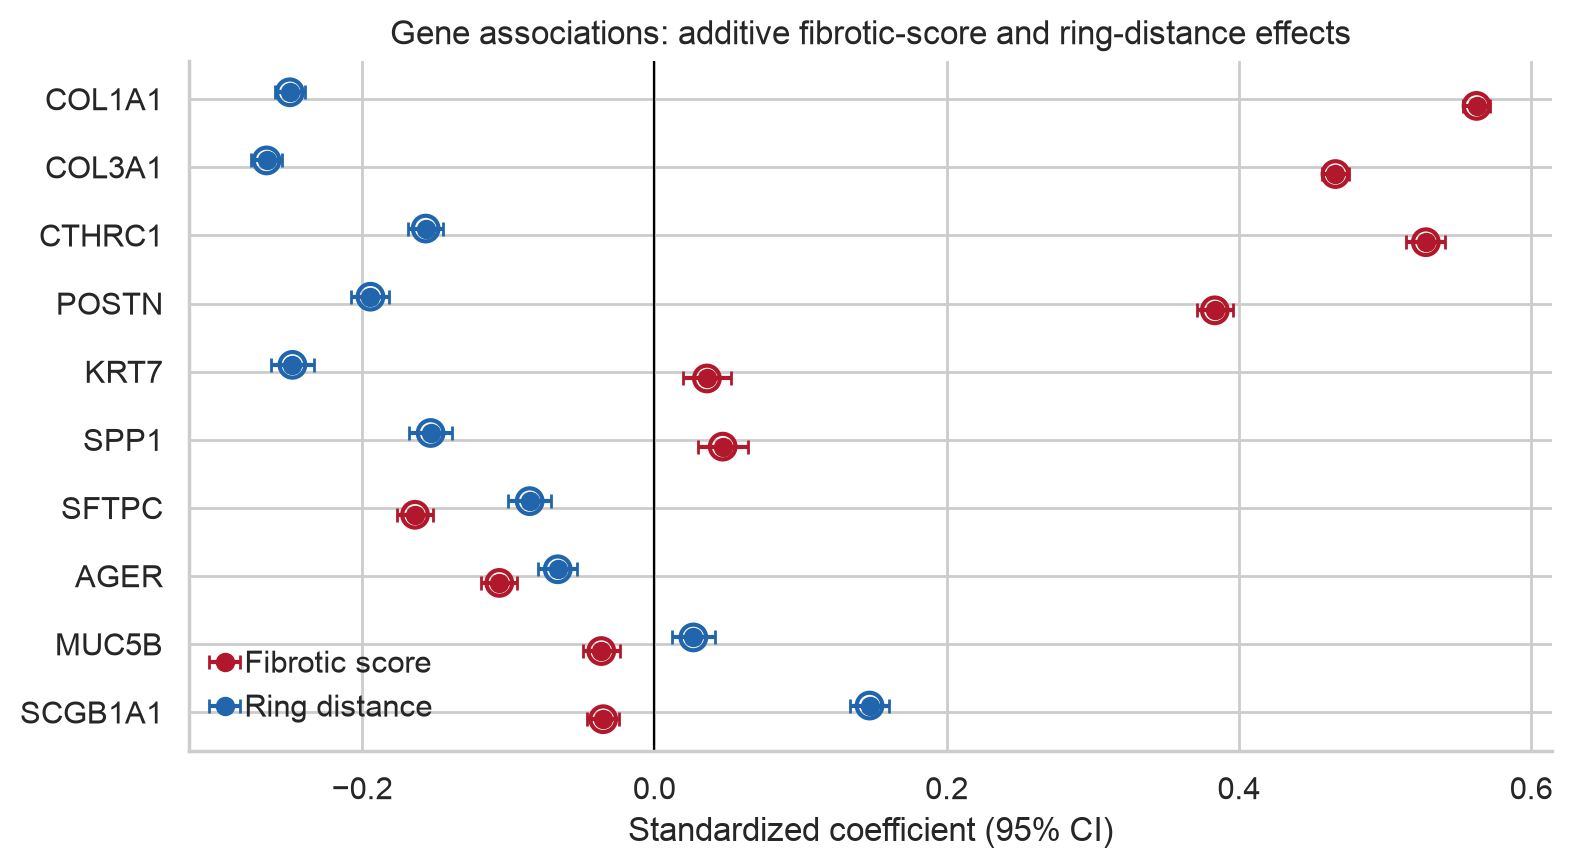

In [20]:
def coefficient_plot(results, feature_order, title):
    plot_data = results.copy()
    plot_data["feature"] = pd.Categorical(plot_data["feature"], categories=feature_order[::-1], ordered=True)
    plot_data = plot_data.sort_values(["feature", "predictor"])

    fig, ax = plt.subplots(figsize=(8, max(4.5, 0.42 * len(feature_order))))
    offsets = {"Fibrotic score": -0.10, "Ring distance": 0.10}
    colors = {"Fibrotic score": "#B2182B", "Ring distance": "#2166AC"}
    positions = {feature: index for index, feature in enumerate(feature_order[::-1])}

    for predictor in ["Fibrotic score", "Ring distance"]:
        subset = plot_data.loc[plot_data["predictor"].eq(predictor)]
        y = np.array([positions[str(feature)] for feature in subset["feature"]]) + offsets[predictor]
        ax.errorbar(
            subset["coefficient"], y,
            xerr=[subset["coefficient"] - subset["ci_low"], subset["ci_high"] - subset["coefficient"]],
            fmt="o", color=colors[predictor], capsize=2.5, label=predictor,
        )
        significant = subset["fdr"].lt(0.05).to_numpy()
        ax.scatter(subset.loc[significant, "coefficient"], y[significant], s=85,
                   facecolors="none", edgecolors=colors[predictor], linewidths=1.5)

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(range(len(feature_order)), feature_order[::-1])
    ax.set_xlabel("Standardized coefficient (95% CI)")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.legend(frameon=False)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

coefficient_plot(gene_results.assign(fdr=model_results.loc[gene_results.index, "fdr"].to_numpy()), genes,
                 "Gene associations: additive fibrotic-score and ring-distance effects")

### Biological interpretation

- **Fibrotic extracellular-matrix genes define the strongest signal.** `COL1A1`, `COL3A1`, `CTHRC1`, and `POSTN` are strongly positively associated with the continuous fibrotic NMF score after adjustment for ring distance and sample. This supports a collagen-rich, activated-fibroblast program in spots with greater fibrotic composition.
- **The same program decreases away from the Fibrotic niche.** The negative ring-distance coefficients for `COL1A1`, `COL3A1`, `CTHRC1`, and `POSTN` show that their expression declines as spots become more spatially distant from Fibrotic spots, even after controlling for fibrotic score.
- `KRT7` and `SPP1` also decrease with distance, consistent with epithelial-remodeling and macrophage-associated signals being concentrated near the fibrotic environment, although their independent associations with fibrotic score are smaller.
- `SFTPC` and `AGER`, markers of differentiated alveolar epithelium, are negatively associated with fibrotic score. Their adjusted ring coefficients are also negative, however, so the fitted result should not be described as simple recovery with distance. It represents a conditional association after simultaneously controlling for fibrotic composition and sample.

Together, the two coefficients distinguish **local fibrotic composition** from **spatial proximity to the Fibrotic niche**. They are associations rather than evidence that the niche directly causes these transcriptional changes.

In [21]:
gene_result_table = model_results.loc[model_results["outcome_type"].eq("Gene")].copy()
gene_result_table.sort_values(["predictor", "fdr", "feature"])

,outcome_type,feature,predictor,coefficient,ci_low,ci_high,p_value,n_spots,r_squared,fdr,significant_fdr_0.05
0,Gene,COL1A1,Fibrotic score,0.562581,0.553236,0.571927,0.000000e+00,30802,0.566184,0.000000e+00,True
2,Gene,COL3A1,Fibrotic score,0.466015,0.456612,0.475419,0.000000e+00,30802,0.529226,0.000000e+00,True
4,Gene,CTHRC1,Fibrotic score,0.527872,0.514444,0.541300,0.000000e+00,30802,0.427947,0.000000e+00,True
6,Gene,POSTN,Fibrotic score,0.383472,0.370993,0.395951,0.000000e+00,30802,0.304309,0.000000e+00,True
12,Gene,SFTPC,Fibrotic score,-0.163801,-0.176220,-0.151383,2.342092e-147,30802,0.061202,6.612966e-147,True
14,Gene,AGER,Fibrotic score,-0.106138,-0.118510,-0.093766,1.918049e-63,30802,0.249006,3.836099e-63,True
18,Gene,SCGB1A1,Fibrotic score,-0.035033,-0.045832,-0.024234,2.042723e-10,30802,0.128060,2.883844e-10,True
16,Gene,MUC5B,Fibrotic score,-0.036350,-0.048924,-0.023777,1.458674e-08,30802,0.093494,2.000468e-08,True
10,Gene,SPP1,Fibrotic score,0.046743,0.029713,0.063772,7.460042e-08,30802,0.150085,9.677892e-08,True
8,Gene,KRT7,Fibrotic score,0.035929,0.019442,0.052416,1.943479e-05,30802,0.107113,2.345641e-05,True


## Signaling-pathway associations

The same additive specification is applied to all 14 precomputed MLM pathway-activity scores.

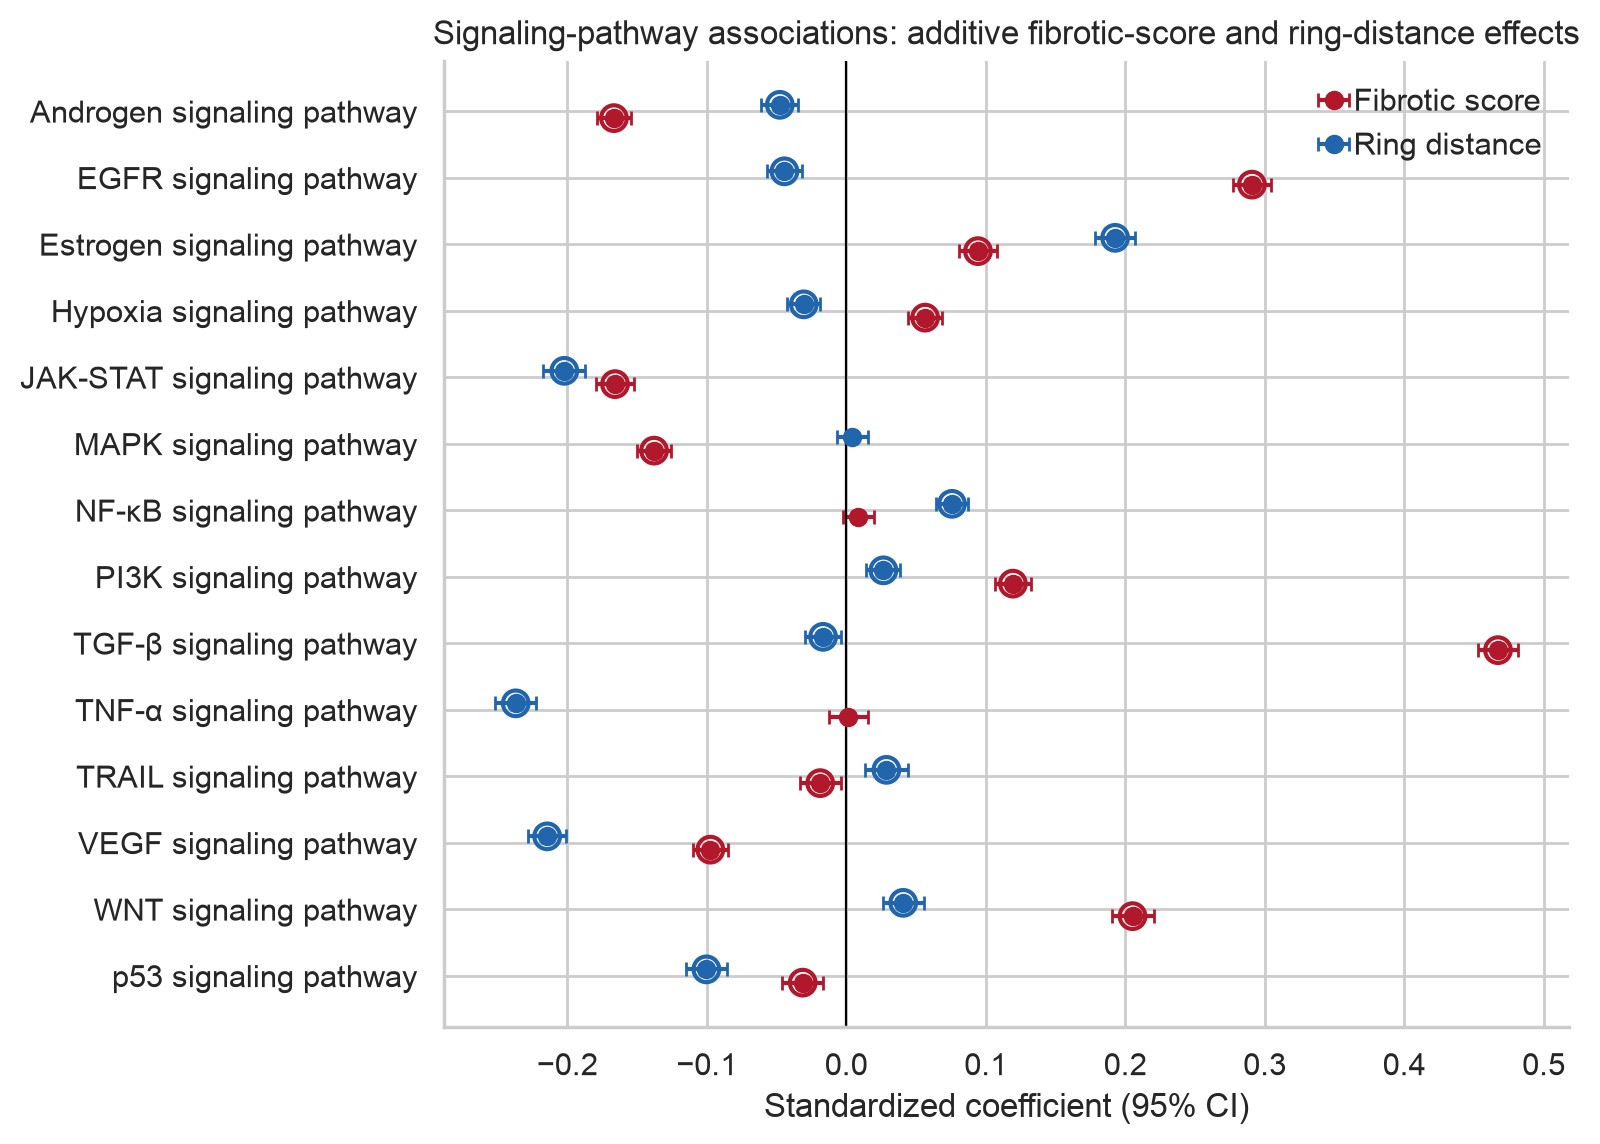

In [22]:
pathway_plot_results = pathway_results.copy()
pathway_plot_results["fdr"] = model_results.loc[
    model_results["outcome_type"].eq("Pathway"), "fdr"
].to_numpy()
coefficient_plot(
    pathway_plot_results,
    pathway_labels,
    "Signaling-pathway associations: additive fibrotic-score and ring-distance effects",
)

### Biological interpretation

- `TGF-β signaling pathway` shows the strongest positive association with fibrotic score, consistent with its established role in fibroblast activation and extracellular-matrix deposition. `EGFR signaling pathway`, `WNT signaling pathway`, and `PI3K signaling pathway` are also positively associated, pointing to coordinated epithelial-remodeling, developmental, and growth-survival signaling in fibrotic-composition-rich spots.
- For `TGF-β signaling pathway`, the fibrotic-score effect is much larger than the ring-distance effect. This suggests that its activity is more closely related to the local molecular composition of a spot than to distance alone.
- `TNF-α signaling pathway`, `VEGF signaling pathway`, and `JAK-STAT signaling pathway` have strong negative ring-distance coefficients: their activities are higher near Fibrotic spots and decline outward after adjustment for fibrotic score and sample. Their fibrotic-score effects are weak or negative, indicating that spatial proximity and local fibrotic composition capture different biological signals.
- `MAPK signaling pathway` is negatively associated with fibrotic score but has no clear independent ring-distance trend after multiple-testing correction. `NF-κB signaling pathway` shows the opposite pattern: little independent fibrotic-score association but a modest positive distance effect.

These findings support several overlapping signaling programs around fibrotic tissue, while also showing why fibrotic score and physical distance should be retained as separate additive predictors.

In [23]:
pathway_result_table = model_results.loc[model_results["outcome_type"].eq("Pathway")].copy()
pathway_result_table.sort_values(["predictor", "fdr", "feature"])

,outcome_type,feature,predictor,coefficient,ci_low,ci_high,p_value,n_spots,r_squared,fdr,significant_fdr_0.05
22,Pathway,EGFR signaling pathway,Fibrotic score,0.290834,0.277305,0.304364,0.000000e+00,30802,0.355054,0.000000e+00,True
36,Pathway,TGF-β signaling pathway,Fibrotic score,0.467241,0.452942,0.481540,0.000000e+00,30802,0.257779,0.000000e+00,True
20,Pathway,Androgen signaling pathway,Fibrotic score,-0.166570,-0.178797,-0.154342,4.826799e-157,30802,0.211700,1.782203e-156,True
44,Pathway,WNT signaling pathway,Fibrotic score,0.205229,0.190160,0.220297,5.451802e-157,30802,0.106235,1.869189e-156,True
28,Pathway,JAK-STAT signaling pathway,Fibrotic score,-0.165793,-0.179428,-0.152159,1.526944e-125,30802,0.063714,3.857542e-125,True
30,Pathway,MAPK signaling pathway,Fibrotic score,-0.137803,-0.149973,-0.125634,3.969598e-109,30802,0.501726,9.527036e-109,True
34,Pathway,PI3K signaling pathway,Fibrotic score,0.119472,0.106473,0.132471,1.519176e-72,30802,0.359098,3.170454e-72,True
42,Pathway,VEGF signaling pathway,Fibrotic score,-0.097431,-0.110111,-0.084751,2.961825e-51,30802,0.186241,5.686705e-51,True
24,Pathway,Estrogen signaling pathway,Fibrotic score,0.094421,0.080878,0.107965,1.659852e-42,30802,0.072328,3.064342e-42,True
26,Pathway,Hypoxia signaling pathway,Fibrotic score,0.056527,0.044211,0.068842,2.342113e-19,30802,0.422054,3.626497e-19,True


## Compact coefficient heatmaps

These heatmaps summarize direction and magnitude only; statistical uncertainty remains available in the coefficient plots and result tables above.

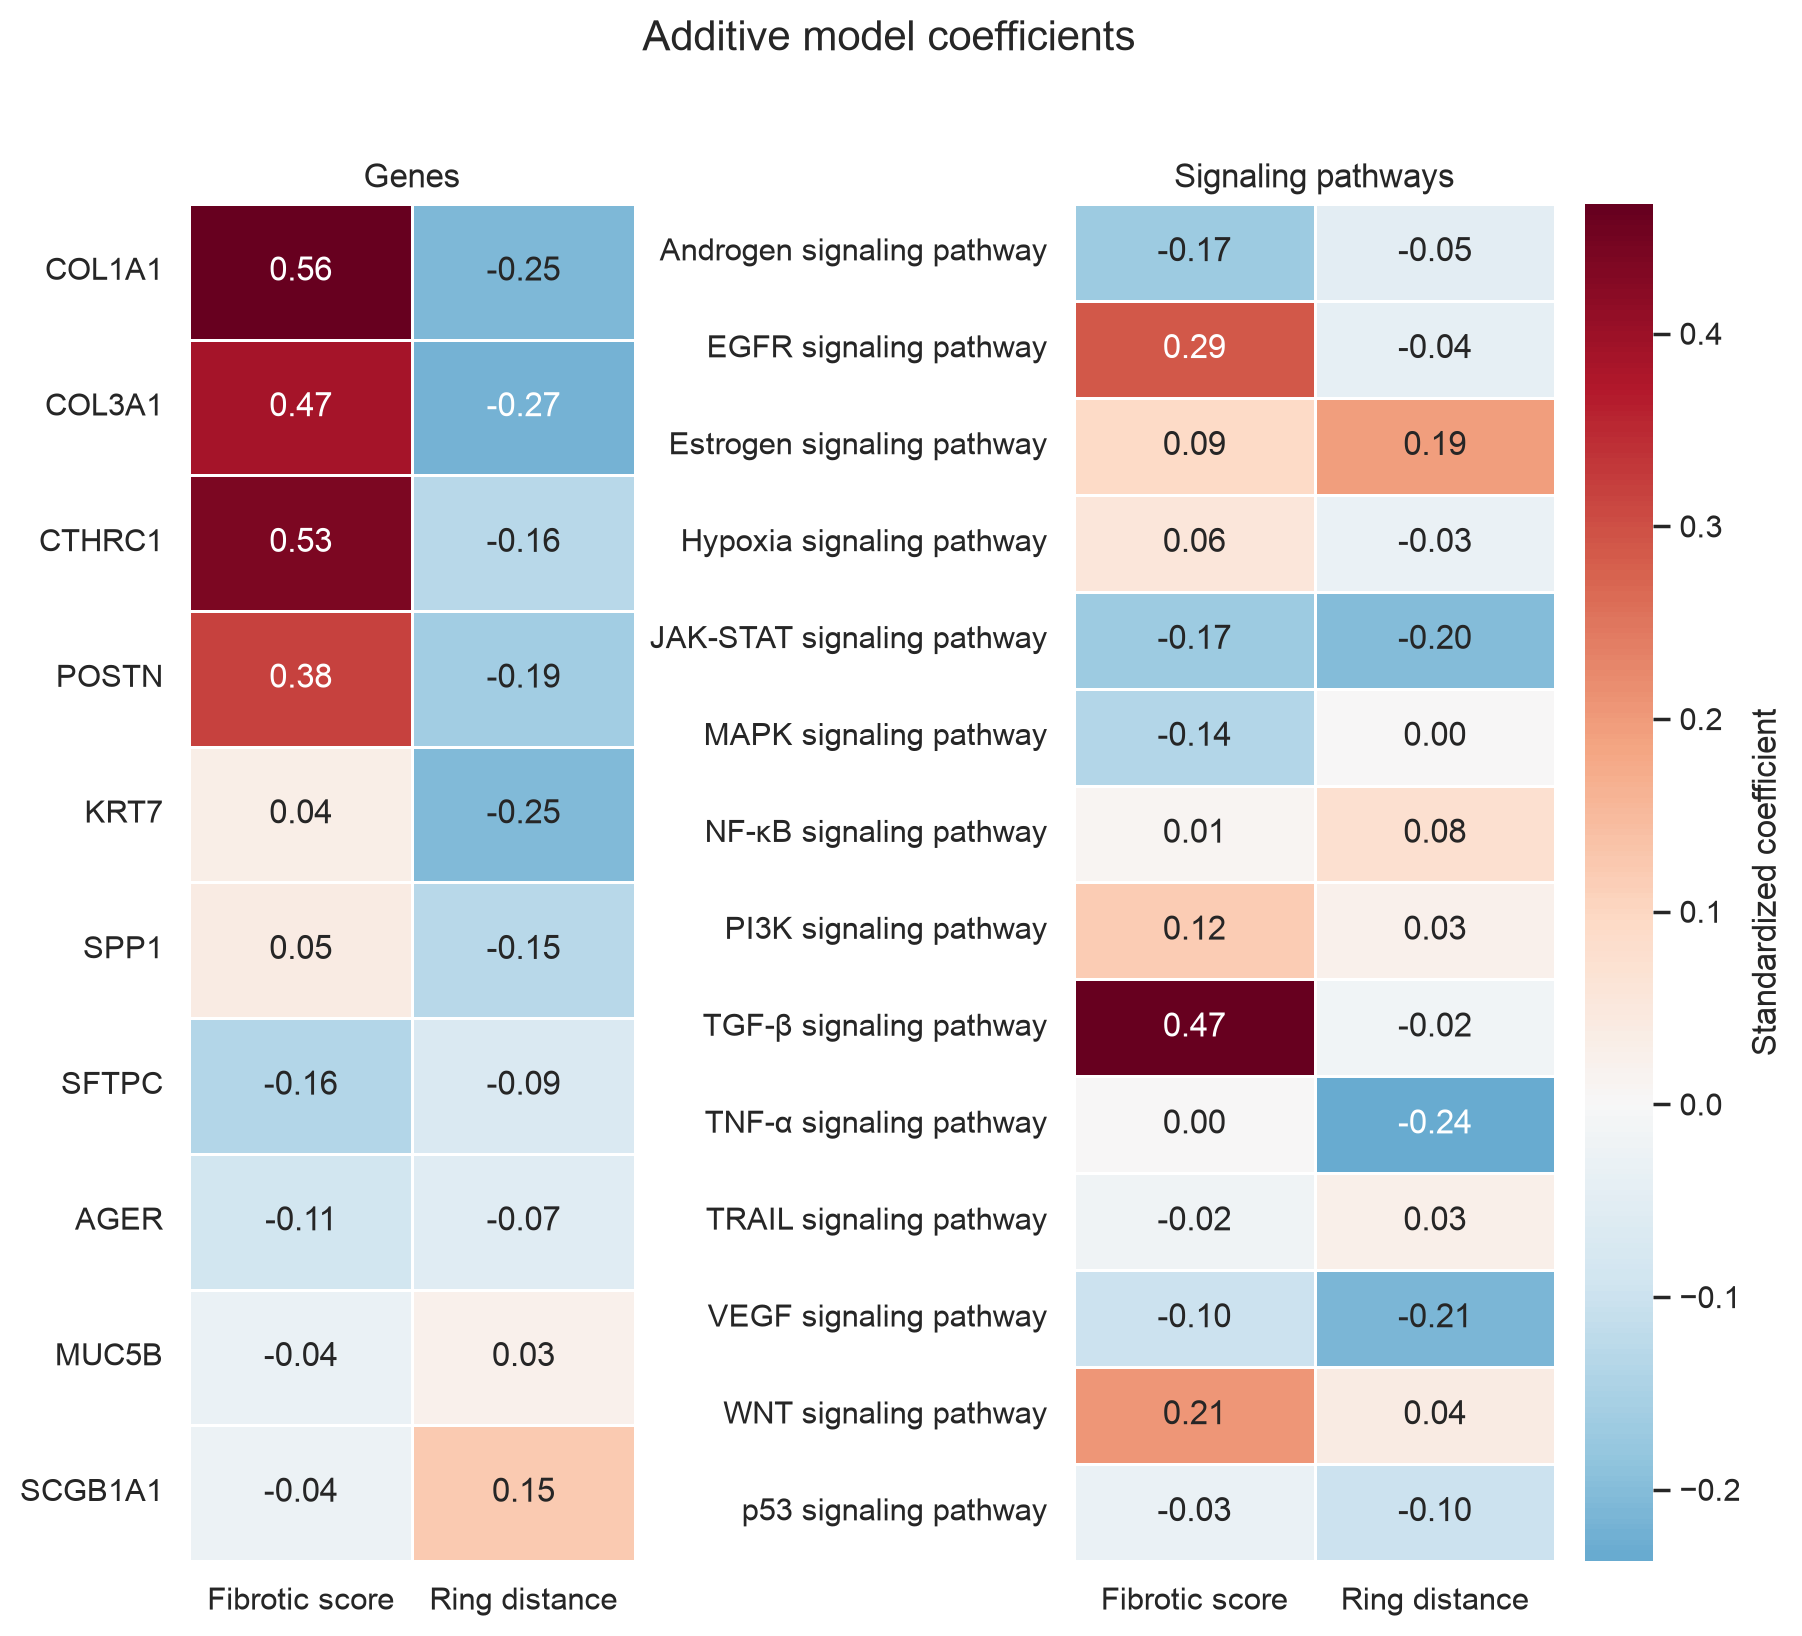

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(9, 8), gridspec_kw={"width_ratios": [1, 1.35]})

for ax, outcome_type, order, title in [
    (axes[0], "Gene", genes, "Genes"),
    (axes[1], "Pathway", pathway_labels, "Signaling pathways"),
]:
    matrix = (
        model_results.loc[model_results["outcome_type"].eq(outcome_type)]
        .pivot(index="feature", columns="predictor", values="coefficient")
        .reindex(order)
        .reindex(columns=["Fibrotic score", "Ring distance"])
    )
    sns.heatmap(matrix, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
                linewidths=0.5, cbar=ax is axes[1], ax=ax,
                cbar_kws={"label": "Standardized coefficient"})
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Additive model coefficients", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Integrated interpretation

The coefficient heatmaps summarize two related but non-equivalent axes of the fibrotic microenvironment:

1. **Fibrotic composition:** high fibrotic score is dominated by matrix-remodeling genes (`COL1A1`, `COL3A1`, `CTHRC1`, `POSTN`) and profibrotic signaling (`TGF-β signaling pathway`, `EGFR signaling pathway`, `WNT signaling pathway`, `PI3K signaling pathway`).
2. **Spatial proximity:** negative ring-distance effects identify signals concentrated near Fibrotic spots and decreasing outward. This pattern is especially clear for the four matrix genes and for `TNF-α signaling pathway`, `VEGF signaling pathway`, and `JAK-STAT signaling pathway` pathway activity.

Because fibrotic score and ring distance are correlated, each coefficient must be read as an effect **conditional on the other predictor and on sample**. The additive model identifies independent average trends but does not test whether the effect of fibrotic composition changes across rings; that interaction is reserved for Notebook 05.

## Summary

- Fibrotic intensity and spatial distance are entered simultaneously, so each coefficient is adjusted for the other predictor.
- Sample fixed effects remove between-section baseline shifts.
- No interaction term is fitted in this notebook.
- Notebook 05 will test whether spatial gradients change with fibrotic intensity or cell-type composition.